# The NBA Regular Season MVP 
There is no formal definition of the Most Valuable Player (MVP) award that comes directly from the NBA itself. It is generally understood to be the best performing player in a given year, but ultimately it is entirely subjective. This makes it quite difficult to predict. Intuition suggests that media narrative is quite important to the NBA MVP voting, which is somewhat difficult to measure. 

In this project, I apply two machine learning methods to the NBA MVP prediction problem. Readers should note that this project is something that I've taken on for fun as I work through various ML texts (namely `Machine Learning with PyTorch and Scikit-Learn` by Raschka, Liu, and Mirjalili).

## Predicting the NBA Regular Season MVP
Much of the NBA regular season's media discourse surrounds the conversation of the Most Valuable Player (MVP). Favorites are established early on as players kick off the season, and the discourse only continues from there. Guys drop out of the conversation as the season goes on, but the conversation persists until the award is announced. Following the announcement is conversation about who was 'robbed' -- who should have been MVP over Player A. Just recently, Shai Gilgeous-Alexander (SGA) was announced as MVP on the same day his OKC Thunder played the San Antonio Spurs in Game 1 of the Western Conference Finals. The game was a fantastic one -- it went to double overtime and ended in a final score of 122-115 in favor of San Antonio. While San Antonio's defensive superstar, Victor Wembanyama, had arguably the best game of his career with 41 points, 24 rebounds, 3 assists and 3 blocks, newly-minted MVP SGA had possibly one of his worst playoff performances of his career shooting the ball at a measly 30% and failing to get to the free throw line. 

Immediately following the loss, discourse on social media was scathing with respect to SGA. Reactionary posts called for him to 'hand the MVP trophy to Wembanyama', and other similar sentiments. This is all to say, the NBA MVP is an incredibly contentious topic. Fans push hard for 'their guy' to win it, and any dips in performance are ridiculed harshly. This project aims to predict the NBA MVP using various ML methods. 

Data for this project comes from `basketball-reference.com`, which is scraped using a user-written API below. 

In [57]:
# Load packages
from basketball_reference_web_scraper import client
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

Next, I gather data using the Basketball Reference scraper. This is a convenient approach since it does not necessitate scrape it myself. Thanks to Jae Bradley, who developed and maintains this scraper.

In [58]:
year_start = 2000
year_end = 2025

dat = []
for year in range(year_start, year_end):
    adv_year = client.players_advanced_season_totals(season_end_year = year)
    df = pd.DataFrame(adv_year)
    df['year']=year
    dat.append(df)

nba = pd.concat(dat, ignore_index= True)

# Retain NBA season for informational purposes
nba['season'] = (nba['year']-1).astype(str) + '-' + nba['year'].astype(str).str[-2:]

Note that the data splits players who were on $K$ teams in a given season into $K$ observations. This will need to be handled down the line.

Next, we need data on who the actual MVPs were in each regular season, so that we can feed the training data some information. We could also incorporate MVP voting shares -- the MVP is not determined by a winner-take-all voting system. Instead, the NBA MVP is determined by a weighted voting (Borda) system, where voters can place a player in either 1st-5th positions, each worth a different number of points. However, the binary MVP outcome should be enough for my purposes. Fortunately, `basketball-reference.com` has an MVP table readily available. 

In [77]:
mvp = pd.read_html('sportsref_download.xls', header=1, encoding = 'utf-8')[0]

# We can keep only the season and player, but will need to do some cleanup first
mvp_short = mvp[['Season', 'Player']].copy()
mvp_short['is_mvp'] = 1
mvp_short.columns = mvp_short.columns.str.lower()

mvp_short = mvp_short.rename(columns = {'player': 'name'})

In [60]:
# Merge onto the player season totals 
nba_mvp = pd.merge(nba, mvp_short, 'left', on = ['name', 'season'])

In [61]:
# Ensure the span of data is correct post-merge
nba_mvp['season'].value_counts()

season
2021-22    715
2023-24    657
2020-21    626
2018-19    622
2022-23    609
2017-18    605
2019-20    591
2014-15    575
2013-14    548
2016-17    542
2010-11    542
2015-16    528
2007-08    527
2004-05    526
2012-13    523
2003-04    517
2008-09    515
2011-12    515
2005-06    512
2009-10    512
2000-01    490
2006-07    487
2001-02    470
1999-00    468
2002-03    456
Name: count, dtype: int64

In [62]:
# Ensure that every year has an MVP 
mvp_per_season = nba_mvp.groupby('season')['is_mvp'].sum()
print(mvp_per_season)

season
1999-00    1.0
2000-01    1.0
2001-02    1.0
2002-03    1.0
2003-04    1.0
2004-05    1.0
2005-06    1.0
2006-07    1.0
2007-08    1.0
2008-09    1.0
2009-10    1.0
2010-11    1.0
2011-12    1.0
2012-13    1.0
2013-14    1.0
2014-15    1.0
2015-16    1.0
2016-17    1.0
2017-18    1.0
2018-19    1.0
2019-20    1.0
2020-21    1.0
2021-22    1.0
2022-23    1.0
2023-24    1.0
Name: is_mvp, dtype: float64


In [63]:
# Replace missing MVP values with 0
nba_mvp['is_mvp'] = nba_mvp['is_mvp'].fillna(0)
nba_mvp['mpg'] = nba_mvp['minutes_played'] / nba_mvp['games_played']

# Clean up positions and team names 
POS_ABBR = {
    'POINT GUARD': 'PG',
    'SHOOTING GUARD': 'SG',
    'SMALL FORWARD': 'SF',
    'POWER FORWARD': 'PF',
    'CENTER': 'C'
}

def clean_positions(val):
    if not isinstance(val, list):
        return val  # already a string or NaN
    parts = [p.value if hasattr(p, 'value') else str(p) for p in val]
    return '/'.join(POS_ABBR.get(p, p) for p in parts)

def clean_team(val):
    s = val.value if hasattr(val, 'value') else str(val)
    return s.title()  # "LOS ANGELES LAKERS" -> "Los Angeles Lakers"

nba_mvp['positions'] = nba_mvp['positions'].apply(clean_positions)
nba_mvp['team']      = nba_mvp['team'].apply(clean_team)

In [64]:
# Save the set in the short term. BBR is limiting my requests, so I cannot gather new data. Don't want to lose this current set!
nba_mvp.to_csv('nba_advanced.csv', index=False)

In [34]:
# Get counting stats for players
# Implement a delay in the requests
import time 

year_start = 2000
year_end = 2025

counting, standings = [], []
for year in range(year_start, year_end):
    print(f"Gathering NBA data from {year}... ")
    try: 
        counting.append(
            pd.DataFrame(client.players_season_totals(season_end_year = year)).assign(year = year)
        )
        time.sleep(5)
        standings.append(
            pd.DataFrame(client.standings(season_end_year = year)).assign(year = year)
        )
        time.sleep(5)
        # In case BBR interupts again, save progress 
        pd.concat(counting, ignore_index=True).to_csv('nba_counting.csv')
        pd.concat(standings, ignore_index = True).to_csv('nba_standings.csv')
    except Exception as error: 
        print(f"  stopped at {year}: {error}")
        break 

Gathering NBA data from 2000... 
Gathering NBA data from 2001... 
Gathering NBA data from 2002... 
Gathering NBA data from 2003... 
Gathering NBA data from 2004... 
Gathering NBA data from 2005... 
Gathering NBA data from 2006... 
Gathering NBA data from 2007... 
Gathering NBA data from 2008... 
Gathering NBA data from 2009... 
Gathering NBA data from 2010... 
Gathering NBA data from 2011... 
Gathering NBA data from 2012... 
Gathering NBA data from 2013... 
Gathering NBA data from 2014... 
Gathering NBA data from 2015... 
Gathering NBA data from 2016... 
Gathering NBA data from 2017... 
Gathering NBA data from 2018... 
Gathering NBA data from 2019... 
Gathering NBA data from 2020... 
Gathering NBA data from 2021... 
Gathering NBA data from 2022... 
Gathering NBA data from 2023... 
Gathering NBA data from 2024... 


In [65]:
# Assemble the data. Note it already ran fully in the loop and saved, so no need to save later.
counting_df = pd.concat(counting, ignore_index = True)
standings_df = pd.concat(standings, ignore_index = True)

# Add in season for both sets
counting_df['season'] = (counting_df['year']-1).astype(str) + '-' + counting_df['year'].astype(str).str[-2:]
standings_df['season'] = (standings_df['year']-1).astype(str) + '-' + standings_df['year'].astype(str).str[-2:]

# Clean up team name
counting_df['team']      = counting_df['team'].apply(clean_team)
standings_df['team'] = standings_df['team'].apply(clean_team)

standings_df = standings_df.rename(columns = {'wins': 'team_wins', 'losses': 'team_losses'})

In [66]:
# Clean up data and prepare for merge with advanced stats and mvp results (nba_mvp)
merge_keys = ['name', 'team', 'year']
drop_from_counting = ['positions', 'age', 'minutes_played'] + [
    c for c in counting_df.columns if c in nba_mvp.columns and c not in merge_keys
]
counting_to_merge = counting_df.drop(columns=drop_from_counting, errors='ignore')

drop_from_standings = ['division', 'conference', 'season'] + [
    c for c in standings_df.columns if c in nba_mvp.columns and c not in merge_keys
]

standings_to_merge = standings_df.drop(columns = drop_from_standings, errors = 'ignore')

In [67]:
# Merge standings and counting stats to set
nba_mvp = nba_mvp.merge(
    counting_to_merge.drop_duplicates(merge_keys),
    on=merge_keys, how='left',
)
nba_mvp = nba_mvp.merge(
    standings_df[['team', 'year', 'team_wins', 'team_losses']].drop_duplicates(['team', 'year']),
    on=['team', 'year'], how='left',
)

### Final preparations for prediction
As mentioned before, traded players in the data from `basketball-reference' have at least two observations. While we may understand this as the same player, machine learning algorithms will not. We need to account for this in the data. Fortunately, no player has ever been traded midseason and won MVP. 

Further, I want to minimize the number of 'noisy' players, or players who do not qualify for the award (whether it be officially or unofficially). Recently, the NBA made it so that only players who played 65+ games could qualify for regular season accolades. However, voters implicitly factored availability into their votes for quite some time. To this end, I filter out players who played less than 50 games in a season. I also filter out players that played less than 30 minutes per game (MPG) -- no MVP has ever played less than 30 MPG, with the closest being Giannis Antetokounmpo in 2019, where he averaged 30.4 MPG.  




In [68]:
# 1) Drop TOT/Total aggregate rows
non_tot = nba_mvp[~nba_mvp['team'].astype(str).str.lower().isin(['tot', 'total'])]

# 2) For traded players, keep the row from the team they played most games for
modeling_df = (non_tot
               .sort_values('games_played', ascending=False)
               .drop_duplicates(['name', 'season'])
               .reset_index(drop=True))

# 3) Filter to MVP-eligible: >= 50 GP and >= 30 MPG
modeling_df = modeling_df[
    (modeling_df['games_played'] >= 50) &
    (modeling_df['mpg'] >= 30)
].reset_index(drop=True)


# Sanity: each season should still have exactly 1 MVP
print("MVPs per season (should all be 1):")
print(modeling_df.groupby('season')['is_mvp'].sum().astype(int).to_string())

# Save as a parquet for quick storage and access
nba_mvp.to_parquet('nba_mvp_final.parquet')

MVPs per season (should all be 1):
season
1999-00    1
2000-01    1
2001-02    1
2002-03    1
2003-04    1
2004-05    1
2005-06    1
2006-07    1
2007-08    1
2008-09    1
2009-10    1
2010-11    1
2011-12    1
2012-13    1
2013-14    1
2014-15    1
2015-16    1
2016-17    1
2017-18    1
2018-19    1
2019-20    1
2020-21    1
2021-22    1
2022-23    1
2023-24    1


In [69]:
# Drop identifier/target/duplicate columns; everything numeric else is fair game
exclude = {'slug', 'name', 'positions', 'team', 'year', 'season', 'is_mvp'}
feature_cols = [c for c in modeling_df.columns
                if c not in exclude and pd.api.types.is_numeric_dtype(modeling_df[c])]

# Within-season percentile rank: compare each player to their peers that season
X = (modeling_df.groupby('season')[feature_cols]
                .rank(pct=True)
                .fillna(0.5))
y = modeling_df['is_mvp'].astype(int)

print(f"Features ({len(feature_cols)}):")
for c in feature_cols:
    print(f"  - {c}")


Features (42):
  - age
  - games_played
  - minutes_played
  - player_efficiency_rating
  - true_shooting_percentage
  - three_point_attempt_rate
  - free_throw_attempt_rate
  - offensive_rebound_percentage
  - defensive_rebound_percentage
  - total_rebound_percentage
  - assist_percentage
  - steal_percentage
  - block_percentage
  - turnover_percentage
  - usage_percentage
  - offensive_win_shares
  - defensive_win_shares
  - win_shares
  - win_shares_per_48_minutes
  - offensive_box_plus_minus
  - defensive_box_plus_minus
  - box_plus_minus
  - value_over_replacement_player
  - is_combined_totals
  - mpg
  - games_started
  - made_field_goals
  - attempted_field_goals
  - made_three_point_field_goals
  - attempted_three_point_field_goals
  - made_free_throws
  - attempted_free_throws
  - offensive_rebounds
  - defensive_rebounds
  - assists
  - steals
  - blocks
  - turnovers
  - personal_fouls
  - points
  - team_wins
  - team_losses


In [70]:
from sklearn.ensemble import RandomForestClassifier

train_mask = modeling_df['year'] <= 2019
test_mask  = modeling_df['year'] >= 2020

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',   # ~1:300 imbalance
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
print(f"Trained on {len(X_train):,} rows ({y_train.sum()} MVPs)")
print(f"Test set:   {len(X_test):,} rows ({y_test.sum()} MVPs)")


Trained on 1,781 rows (20 MVPs)
Test set:   395 rows (5 MVPs)


 season         predicted_mvp  mvp_prob            actual_mvp  is_mvp
2019-20 Giannis Antetokounmpo     0.442 Giannis Antetokounmpo     1.0
2020-21 Giannis Antetokounmpo     0.162          Nikola Jokić     0.0
2021-22          Nikola Jokić     0.216          Nikola Jokić     1.0
2022-23           Joel Embiid     0.258           Joel Embiid     1.0
2023-24          Nikola Jokić     0.366          Nikola Jokić     1.0

Top-1 accuracy: 4/5 = 80.0%
Top-3 accuracy: 5/5 = 100.0%


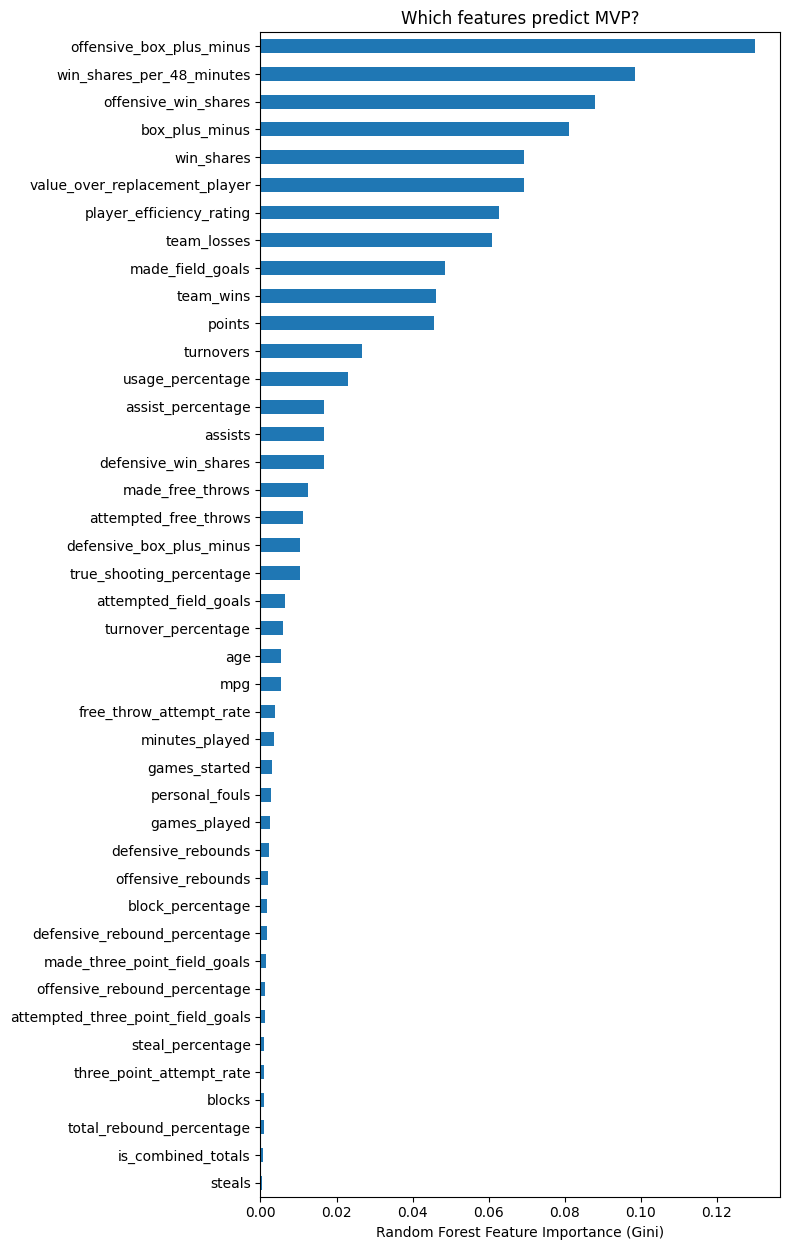

In [71]:
test_results = modeling_df.loc[test_mask, ['season', 'name', 'is_mvp']].copy()
test_results['mvp_prob'] = rf.predict_proba(X_test)[:, 1]

# Top-1 per season
predicted_mvps = (test_results
                  .sort_values('mvp_prob', ascending=False)
                  .groupby('season').head(1)
                  .sort_values('season')
                  .rename(columns={'name': 'predicted_mvp'}))
actual_mvps = (test_results[test_results['is_mvp'] == 1][['season', 'name']]
               .rename(columns={'name': 'actual_mvp'}))
comparison = predicted_mvps.merge(actual_mvps, on='season')[
    ['season', 'predicted_mvp', 'mvp_prob', 'actual_mvp', 'is_mvp']]
print(comparison.to_string(index=False))

correct = int(comparison['is_mvp'].sum())
print(f"\nTop-1 accuracy: {correct}/{len(comparison)} = {correct/len(comparison):.1%}")

top3 = (test_results.sort_values('mvp_prob', ascending=False)
        .groupby('season').head(3))
top3_correct = int(top3.groupby('season')['is_mvp'].max().sum())
print(f"Top-3 accuracy: {top3_correct}/{len(comparison)} = {top3_correct/len(comparison):.1%}")

# Feature importance
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(importances))))
importances.plot(kind='barh', ax=ax)
ax.set_xlabel('Random Forest Feature Importance (Gini)')
ax.set_title('Which features predict MVP?')
plt.tight_layout()
plt.show()


 season         predicted_mvp  xgb_prob            actual_mvp  is_mvp
2019-20 Giannis Antetokounmpo  0.995823 Giannis Antetokounmpo     1.0
2020-21          Nikola Jokić  0.248030          Nikola Jokić     1.0
2021-22          Nikola Jokić  0.757088          Nikola Jokić     1.0
2022-23 Giannis Antetokounmpo  0.940663           Joel Embiid     0.0
2023-24          Nikola Jokić  0.947591          Nikola Jokić     1.0

XGBoost Top-1: 4/5 = 80.0%
XGBoost Top-3: 5/5 = 100.0%


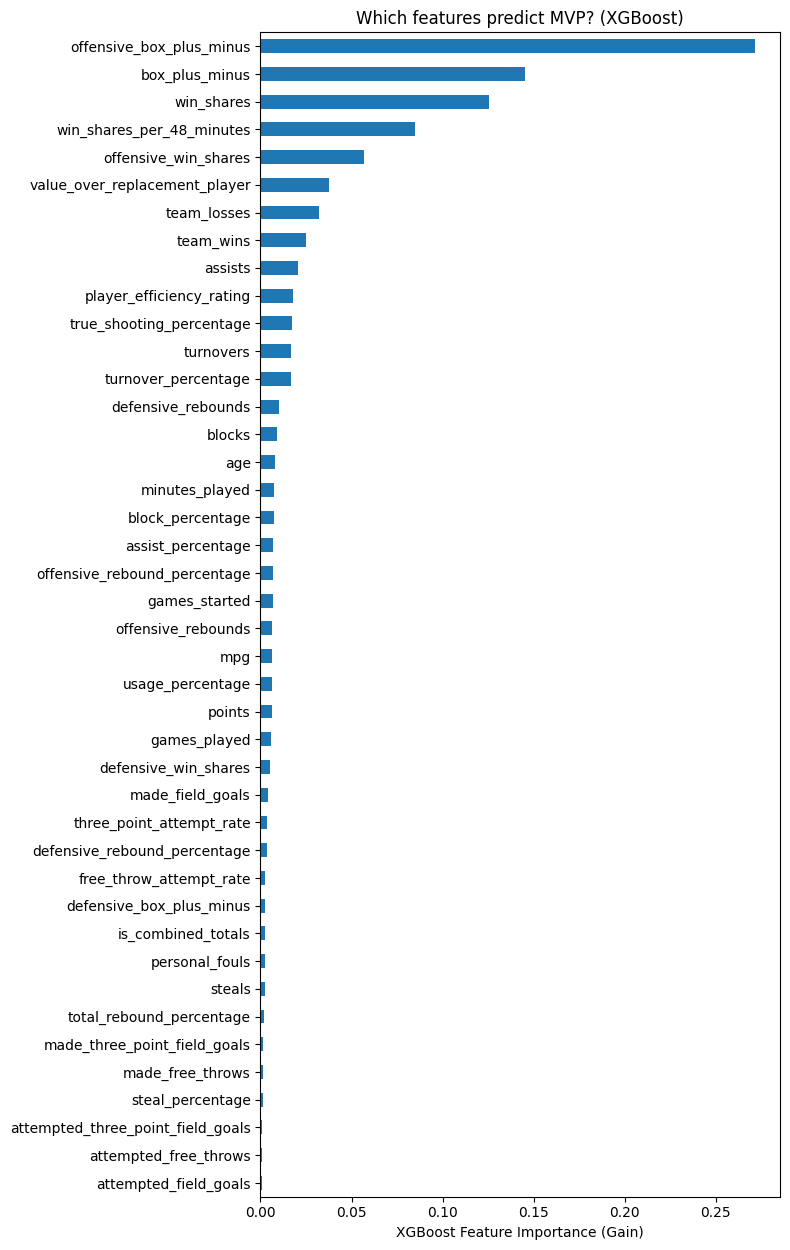

In [72]:
from xgboost import XGBClassifier

pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,                # shallow trees — only 20 MVPs in training
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
)
xgb.fit(X_train, y_train)

# Evaluate same way as RF
test_results['xgb_prob'] = xgb.predict_proba(X_test)[:, 1]

predicted_mvps_xgb = (test_results
                     .sort_values('xgb_prob', ascending=False)
                     .groupby('season').head(1)
                     .sort_values('season')
                     .rename(columns={'name': 'predicted_mvp'}))

comparison_xgb = predicted_mvps_xgb.merge(actual_mvps, on='season')[
    ['season', 'predicted_mvp', 'xgb_prob', 'actual_mvp', 'is_mvp']]
print(comparison_xgb.to_string(index=False))

correct_xgb = int(comparison_xgb['is_mvp'].sum())
print(f"\nXGBoost Top-1: {correct_xgb}/{len(comparison_xgb)} = {correct_xgb/len(comparison_xgb):.1%}")

top3_xgb = (test_results.sort_values('xgb_prob', ascending=False)
            .groupby('season').head(3))
top3_xgb_correct = int(top3_xgb.groupby('season')['is_mvp'].max().sum())
print(f"XGBoost Top-3: {top3_xgb_correct}/{len(comparison_xgb)} = {top3_xgb_correct/len(comparison_xgb):.1%}")

# Feature importance
xgb_importances = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(xgb_importances))))
xgb_importances.plot(kind='barh', ax=ax)
ax.set_xlabel('XGBoost Feature Importance (Gain)')
ax.set_title('Which features predict MVP? (XGBoost)')
plt.tight_layout()
plt.show()


## Quick takeaways
1. XGBoost and Random Forest both perform surprisingly well. Both methods predict four out of five MVPs correctly, and the correct MVP is always in the top 3 predictions. 
2. Both RF and XGBoost find offensive box +/- to be the most important predictor of winning the MVP award. 
3. Each model got a different MVP wrong, but both predicted Giannis to be the MVP over the true MVP. 

### Areas for improvement 
As mentioned in the beginning of this document, this exercise is primarily for fun. I would caution taking any of these predictions as fact. There are some areas where this exercise could be improved. First, as mentioned at the beginning of this post, media narrative is seemingly an important factor in the MVP race. A more sophisticated approach might account for some measure of media presence/discussion of the player in question. Second, despite the filtrations made to the data, there are still far more 'failures' than 'successes' with regards to the training set. Finally, this analysis would be improved substantially by accounting for vote shares. Unfortunately, NBA MVP voting is not readily available from the user-written BBR scraper, and engaging in a scraping exercise is outside of the scope of this write-up. I may do this in the future!